<a href="https://colab.research.google.com/github/bavucadoz/PCVK-Ganjil-2026/blob/main/Week6_03.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **D. Praktikum Filter**

In [1]:
NAMA = 'Arya Bayu Samodra'
NIM = '244107020162'
print(NAMA, NIM)

Arya Bayu Samodra 244107020162


In [2]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [3]:
import numpy as np
import matplotlib.pyplot as plt
import cv2 as cv
import math
from google.colab.patches import cv2_imshow
from PIL import Image as im

In [24]:
def convolution2d(image, kernel, stride=1, padding=0):
    if padding > 0:
        image_padded = np.pad(image, padding, mode='constant', constant_values=0)
    else:
        image_padded = image.copy()

    img_h, img_w = image_padded.shape
    k_h, k_w = kernel.shape

    out_h = math.floor((img_h - k_h) / stride) + 1
    out_w = math.floor((img_w - k_w) / stride) + 1

    output = np.zeros((out_h, out_w), dtype=np.float32)

    for y in range(0, out_h):
        for x in range(0, out_w):
            region = image_padded[y*stride:y*stride+k_h, x*stride:x*stride+k_w]
            output[y, x] = np.sum(region * kernel)

    output = np.clip(output, 0, 255)
    return output.astype(np.uint8)

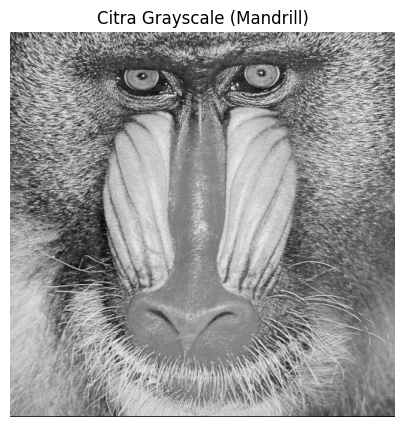

In [26]:
img = cv.imread('/content/drive/MyDrive/PCVK/Images/mandrill.tiff')
img_gray = cv.cvtColor(img, cv.COLOR_BGR2GRAY)

plt.figure(figsize=(5, 5))
plt.imshow(img_gray, cmap='gray')
plt.title('Citra Grayscale (Mandrill)')
plt.axis('off')
plt.show()

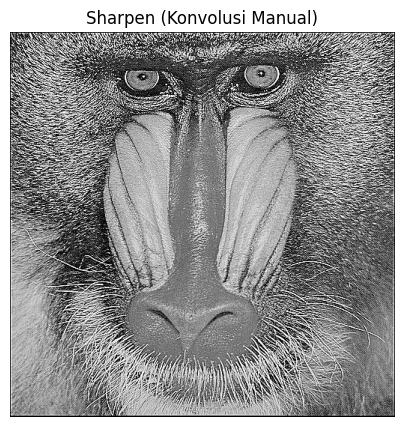

In [27]:
# Menentukan kernel sharpen
kernel_sharpen = np.array([[0, -1, 0],
                           [-1, 5, -1],
                           [0, -1, 0]])

# Memanggil fungsi konvolusi manual
result_sharpen = convolution2d(img_gray, kernel_sharpen, stride=1, padding=2)

# Menampilkan hasil
plt.figure(figsize=(5, 5))
plt.imshow(result_sharpen, cmap='gray')
plt.title('Sharpen (Konvolusi Manual)')
plt.axis('off')
plt.show()

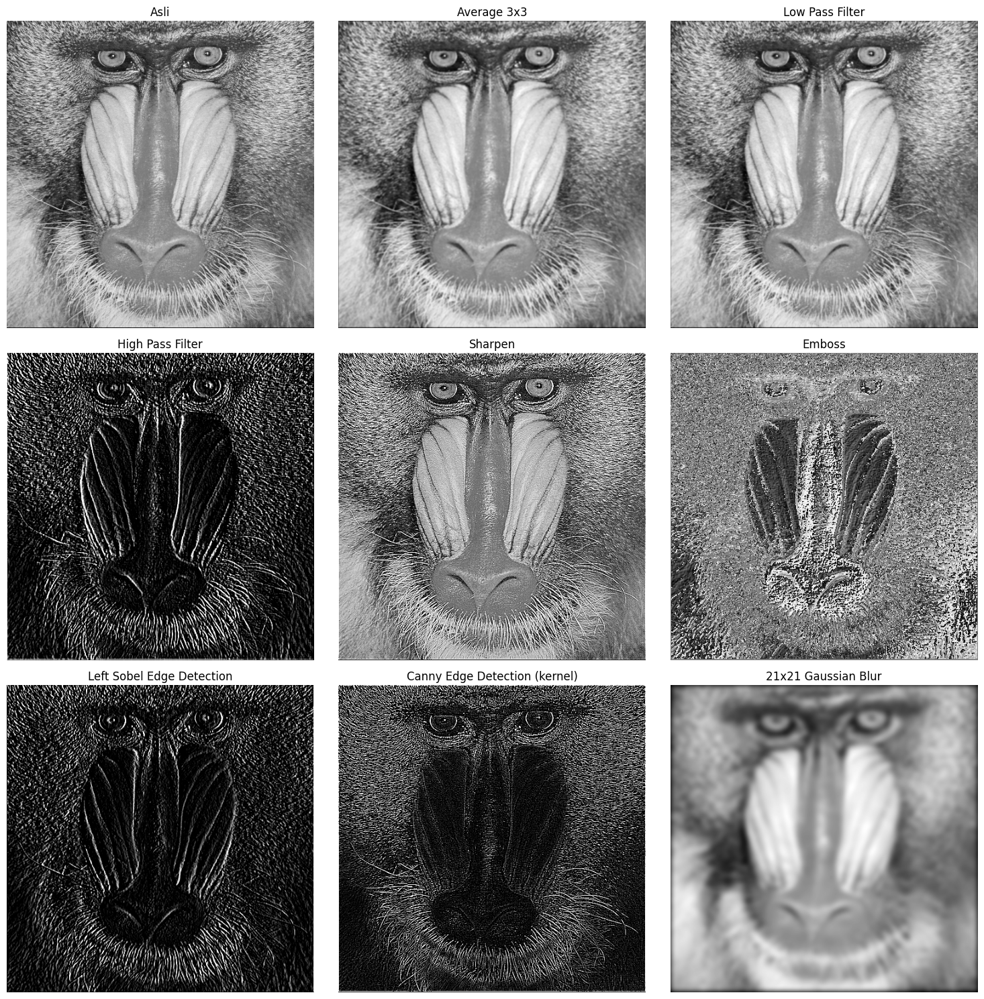

In [31]:
kernel_size = 21
sigma = math.sqrt(kernel_size)
g1d = cv.getGaussianKernel(kernel_size, sigma)       # hanya untuk membangkitkan koefisien kernel
gauss_kernel = g1d @ g1d.transpose()

filters = {
    'Average 3x3'                  : (np.ones((3,3)) / 9,                                       'plain'),
    'Low Pass Filter'              : (np.array([[1,1,1],[1,4,1],[1,1,1]]) / 12,            'plain'),
    'High Pass Filter'             : (np.array([[-1,0,1],[-1,0,3],[-3,0,1]]),              'abs'),
    'Sharpen'                      : (np.array([[0,-1,0],[-1,5,-1],[0,-1,0]]),             'plain'),
    'Emboss'                       : (np.array([[-2,-1,0],[-1,1,1],[0,1,2]]),              'emboss'),
    'Left Sobel Edge Detection'    : (np.array([[1,0,-1],[2,0,-2],[1,0,-1]]),              'abs'),
    'Canny Edge Detection (kernel)': (np.array([[-1,-1,-1],[-1,8,-1],[-1,-1,-1]]),         'abs'),
    '21x21 Gaussian Blur'          : (gauss_kernel,                                       'plain'),
}

def terapkan(gray, kernel, mode):
    r = convolution2d(gray, kernel, stride=1, padding=kernel.shape[0] // 2)
    if mode == 'abs':
        r = np.abs(r)
    elif mode == 'emboss':
        r = r + 128
    r = np.clip(r, 0, 255)
    return r.astype(np.uint8)

hasil_filter = {}
for nama, (k, mode) in filters.items():
    hasil_filter[nama] = terapkan(img_gray, k, mode)

images = [img_gray] + list(hasil_filter.values())
titles = ['Asli'] + list(hasil_filter.keys())

cols = 3
rows = math.ceil(len(images) / cols)

plt.figure(figsize=(cols * 5, rows * 5))
for i, (img_item, title_item) in enumerate(zip(images, titles)):
    plt.subplot(rows, cols, i + 1)
    plt.imshow(img_item, cmap='gray')
    plt.title(title_item)
    plt.axis('off')

plt.tight_layout()
plt.show()



---


# **E. FILTER LIBRARY DAN FILTER MODERN**

**Percobaan 1 - Gaussian, Sharpen, dan Canny dengan `filter2D` (citra RGB)**

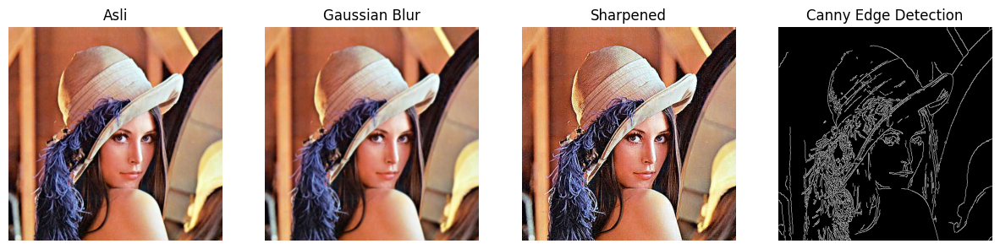

In [5]:
# Fungsi tampil berdampingan
def show_side_by_side(images, titles, figsize=(15,5)):
    plt.figure(figsize=figsize)
    for i, (img_, title) in enumerate(zip(images, titles)):
        if len(img_.shape) == 2:  # grayscale
            plt.subplot(1, len(images), i+1)
            plt.imshow(img_, cmap="gray")
        else:  # color
            plt.subplot(1, len(images), i+1)
            plt.imshow(cv.cvtColor(img_, cv.COLOR_BGR2RGB))
        plt.title(title)
        plt.axis("off")
    plt.show()

img = cv.imread('/content/drive/MyDrive/PCVK/Images/lena.jpg')
img_gray = cv.cvtColor(img, cv.COLOR_BGR2GRAY)

blur = cv.GaussianBlur(img, (7,7), 1)
edges = cv.Canny(cv.cvtColor(img, cv.COLOR_BGR2GRAY), 100, 200)
sharpen_kernel = np.array([[0,-1,0],[-1,5,-1],[0,-1,0]])
sharpened = cv.filter2D(img, -1, sharpen_kernel)
show_side_by_side([img, blur, sharpened, edges],
                  ["Asli", "Gaussian Blur", "Sharpened", "Canny Edge Detection"])

**Percobaan 2 - Filter modern: Bilateral dan Edge Preserving**

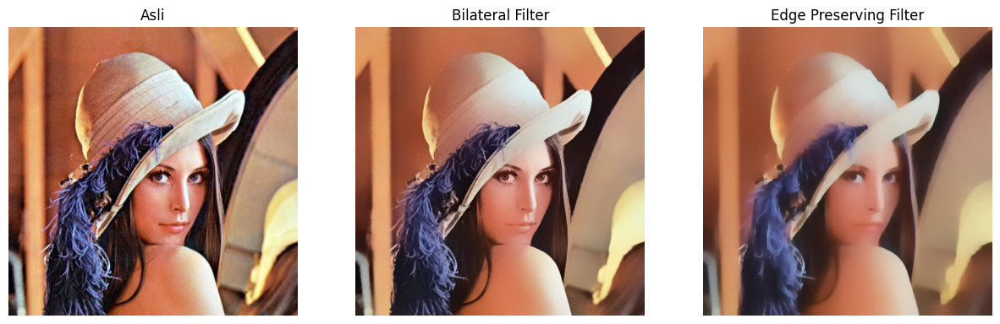

In [6]:
#Filter Modern dari OpenCV
# Bilateral Filter (edge-preserving)
bilateral = cv.bilateralFilter(img, 50, 100, 100)

# Edge Preserving Filter (alternatif Guided Filter)
edge_preserve = cv.edgePreservingFilter(img, flags=1, sigma_s=100, sigma_r=0.9)

show_side_by_side([img, bilateral, edge_preserve],
                  ["Asli", "Bilateral Filter", "Edge Preserving Filter"])

**Percobaan 3 - Filtering pada CNN (Feature Map)**

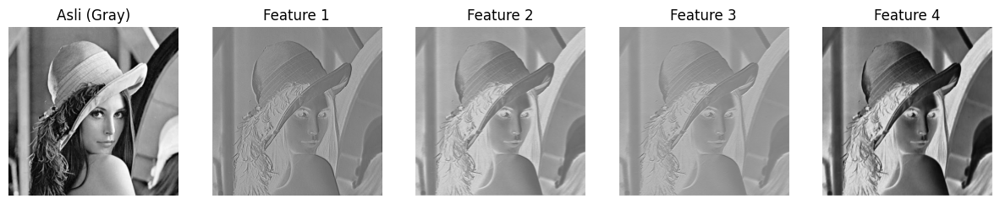

Kernel feature 1:
[[ 0.21 -0.04  0.03]
 [-0.27 -0.26  0.22]
 [-0.19  0.28 -0.09]]
bias = -0.15

Kernel feature 2:
[[ 0.26  0.1   0.13]
 [-0.27 -0.14 -0.1 ]
 [-0.28  0.05 -0.25]]
bias = 0.17

Kernel feature 3:
[[ 0.31  0.27  0.06]
 [-0.24 -0.19 -0.29]
 [-0.29 -0.02  0.12]]
bias = 0.06

Kernel feature 4:
[[ 0.28 -0.29 -0.14]
 [-0.03 -0.3  -0.23]
 [-0.02 -0.26 -0.26]]
bias = 0.28



In [11]:
#Filter Feature Map yang digunakan pada CNN, lakukan running code bagian ini beberapa kali dan perhatikan hasilnya
try:
    import torch
    import torch.nn as nn

    class SimpleCNN(nn.Module):
        def __init__(self):
            super(SimpleCNN, self).__init__()
            self.conv1 = nn.Conv2d(1, 4, kernel_size=3, stride=1, padding=1)

        def forward(self, x):
            return self.conv1(x)

    model = SimpleCNN()

    # Ubah gambar ke tensor
    img_tensor = torch.tensor(img_gray, dtype=torch.float32).unsqueeze(0).unsqueeze(0) / 255.0

    # Hasil CNN
    with torch.no_grad():
        features = model(img_tensor)

    # Visualisasi feature maps
    feature_maps = [features[0,i].numpy() for i in range(features.shape[1])]
    show_side_by_side([img_gray] + feature_maps, ["Asli (Gray)"] + [f"Feature {i+1}" for i in range(len(feature_maps))])

    # Bobot kernel 3x3 yang dipakai tiap feature map (berubah setiap run)
    np.set_printoptions(precision=2, suppress=True)
    for i, w in enumerate(model.conv1.weight.detach().numpy()[:, 0]):
        print(f'Kernel feature {i+1}:\n{w}\nbias = {model.conv1.bias[i].item():.2f}\n')
except ImportError:
    print('PyTorch belum terpasang. Di Colab sudah tersedia; lokal: pip install torch')

= **Kesimpulan Percobaan 3:**
- Setiap feature map adalah hasil konvolusi citra dengan satu kernel 3×3 + bias, persis seperti filter spasial di bagian Praktikum D. Bedanya, nilai kernel tidak ditentukan manual melainkan dipelajari lewat training.
- Karena bobot diinisialisasi acak, tiap kali sel dijalankan hasilnya berbeda: ada yang menyerupai blur, ada yang menonjolkan tepi/tekstur, ada yang hanya mengubah kecerahan/kontras. Ini menunjukkan bahwa layer awal CNN bertindak sebagai kumpulan filter.
- Setelah dilatih, kernel-kernel ini akan menyesuaikan diri menjadi detektor fitur yang berguna bagi tugasnya (tepi arah tertentu, tekstur, warna), sedangkan kernel Sobel/Gaussian pada bagian D bersifat tetap.

**Percobaan 4 - Efek Beauty dan Vintage**

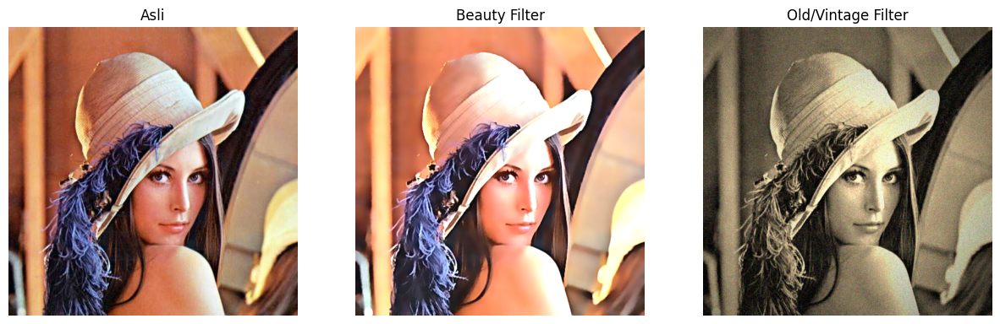

In [12]:
# =====================
# 1. Beauty Filter
# =====================
# Step 1: Smoothing kulit dengan bilateral filter
smooth = cv.bilateralFilter(img, d=15, sigmaColor=75, sigmaSpace=75)

# Step 2: Unsharp masking (pertajam mata/bibir)
gaussian = cv.GaussianBlur(smooth, (0,0), 3)
sharpened = cv.addWeighted(smooth, 1.5, gaussian, -0.5, 0)

# Step 3: Brightness & contrast
alpha = 1.2  # contrast
beta = 15    # brightness
beauty = cv.convertScaleAbs(sharpened, alpha=alpha, beta=beta)

# =====================
# 2. Old/Vintage Filter
# =====================
# Step 1: Sepia tone
sepia_kernel = np.array([[0.272, 0.534, 0.131],
                         [0.349, 0.686, 0.168],
                         [0.393, 0.769, 0.189]])
sepia = cv.transform(img, sepia_kernel)
sepia = np.clip(sepia, 0, 255).astype(np.uint8)

# Step 2: Vignette
rows, cols = img.shape[:2]
kernel_x = cv.getGaussianKernel(cols, cols*0.6)
kernel_y = cv.getGaussianKernel(rows, rows*0.6)
kernel = kernel_y * kernel_x.T
mask = kernel / kernel.max()
vignette = np.copy(sepia)
for i in range(3):
    vignette[:,:,i] = vignette[:,:,i] * mask

# Step 3: Noise/Grain
noise = np.random.normal(0, 15, vignette.shape).astype(np.int16)
old_img = np.clip(vignette.astype(np.int16) + noise, 0, 255).astype(np.uint8)

show_side_by_side([img, beauty, old_img], ["Asli", "Beauty Filter", "Old/Vintage Filter"])

**Percobaan 5 - Filter Anime / Cartoon**

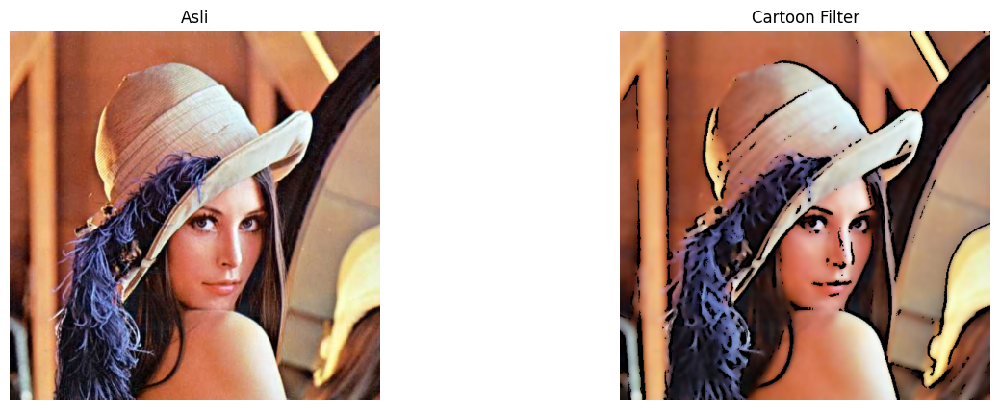

In [13]:
#Filter Anime / Cartoon
# Step 1: Edge detection (pakai median blur dulu agar gambar menjadi lebih halus)
gray = cv.cvtColor(img, cv.COLOR_BGR2GRAY)
gray_blur = cv.medianBlur(gray, 7)
edges = cv.adaptiveThreshold(gray_blur, 255,
                             cv.ADAPTIVE_THRESH_MEAN_C,
                             cv.THRESH_BINARY, 9, 9)

# Step 2: Bilateral filter untuk smoothing warna
color = cv.bilateralFilter(img, d=9, sigmaColor=200, sigmaSpace=200)

# Step 3: Gabungkan (cartoonize)
cartoon = cv.bitwise_and(color, color, mask=edges)

# Tampilkan
show_side_by_side([img, cartoon], ["Asli", "Cartoon Filter"])

**Percobaan 6 – Filter Malam**

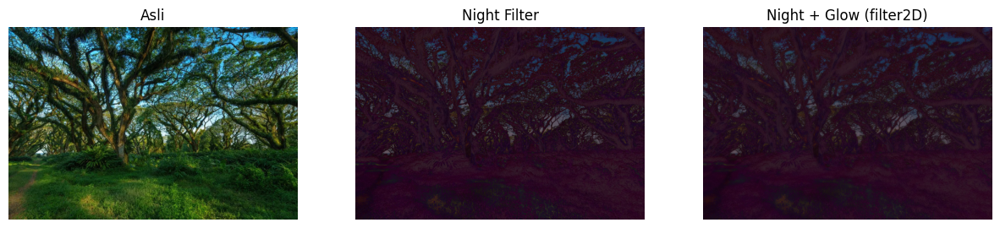

In [19]:
#Night Filter
img = cv.imread('/content/drive/MyDrive/PCVK/Images/djawatan.jpg')
img_gray = cv.cvtColor(img,cv.COLOR_BGR2GRAY)

# Step 1: Gelapkan (contrast turun, brightness negatif)
night = cv.convertScaleAbs(img, alpha=0.6, beta=-40)

# Step 2: Tambah bias biru
blue_tint = np.full_like(night, (50, 0, 100))  # BGR
night = cv.addWeighted(night, 0.8, blue_tint, 0.2, 0)

# Step 3: Efek glow di area terang dengan filter2D (blur kernel)
kernel = np.ones((15,15), np.float32) / 225
glow = cv.filter2D(night, -1, kernel)

# Kombinasikan asli + glow
night_glow = cv.addWeighted(night, 0.7, glow, 0.3, 0)

show_side_by_side([img, night, night_glow],
                  ["Asli", "Night Filter", "Night + Glow (filter2D)"])

**Percobaan 7 - Filter Pagi dan Pagi + Kabut**

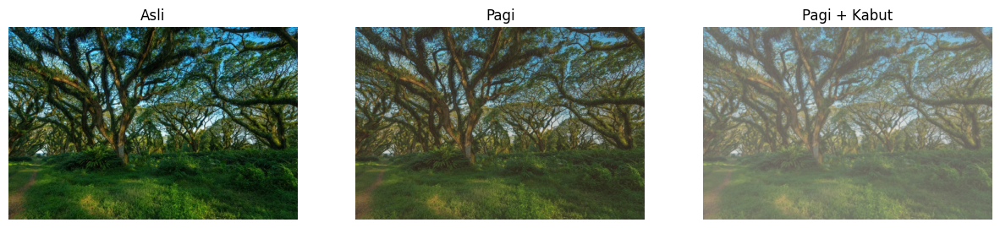

In [21]:
#Filter Suasana pagi dan Kabut
# =========================
# Step 1: Kurangi kontras & cerahkan
# =========================
alpha = 0.9   # contrast
beta = 20     # brightness
soft = cv.convertScaleAbs(img, alpha=alpha, beta=beta)

# =========================
# Step 2: Tambahkan warm tone (kemerahan / oranye)
# =========================
warm_tint = np.full_like(soft, (40, 70, 120))  # BGR
pagi = cv.addWeighted(soft, 0.8, warm_tint, 0.2, 0)

# =========================
# Step 3: Tambahkan haze (kabut tipis) dengan filter2D
# =========================
# Kernel blur Gaussian-like untuk menciptakan efek kabut
kernel = cv.getGaussianKernel(3, 3)
kernel = kernel @ kernel.T  # jadikan 2D kernel
kabut = cv.filter2D(pagi, -1, kernel)

# tambah layer putih untuk kabut lebih nyata
white_layer = np.full_like(pagi, 255)
kabut = cv.addWeighted(kabut, 0.7, white_layer, 0.3, 0)

show_side_by_side([img, pagi, kabut],
                  ["Asli", "Pagi", "Pagi + Kabut"])



---


# **TUGAS PRAKTIKUM**

**Tugas 1 - Analisis: Mean Filter vs Median Filter pada noise *Salt and Pepper***

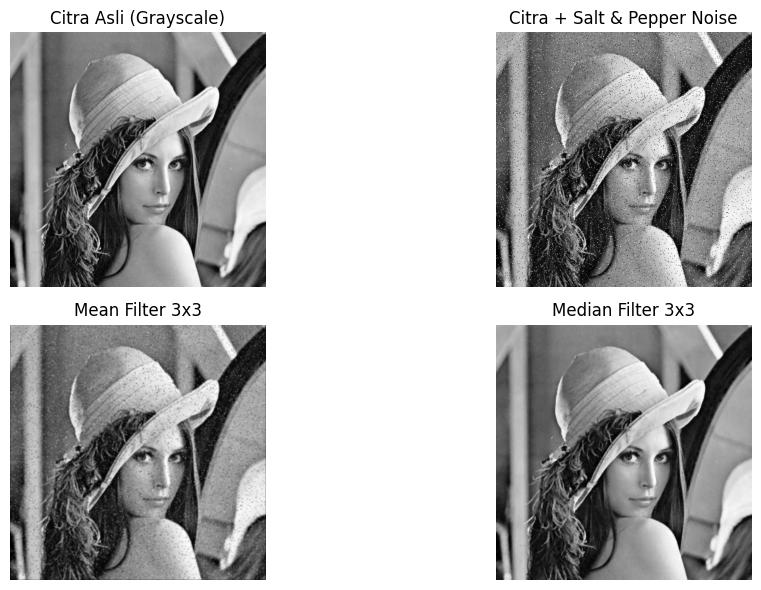

In [35]:
import cv2 as cv
import numpy as np
import matplotlib.pyplot as plt
import math

image = cv.imread('/content/drive/MyDrive/PCVK/Images/lena.jpg')
img_gray = cv.cvtColor(image, cv.COLOR_BGR2GRAY)

def add_salt_and_pepper_noise(image, prob):
    """
    Menambahkan noise salt & pepper ke citra.
    prob: probabilitas/rasio piksel yang akan diubah (misal: 0.05 untuk 5%)
    """
    noisy_image = image.copy()
    num_salt = np.ceil(prob * image.size * 0.5)
    num_pepper = np.ceil(prob * image.size * 0.5)

    # Tambahkan salt (titik-titik putih / nilai 255)
    coords = [np.random.randint(0, i - 1, int(num_salt)) for i in image.shape]
    noisy_image[tuple(coords)] = 255

    # Tambahkan pepper (titik-titik hitam / nilai 0)
    coords = [np.random.randint(0, i - 1, int(num_pepper)) for i in image.shape]
    noisy_image[tuple(coords)] = 0

    return noisy_image

def add_noise(image, amount=0.05):
    output = image.copy()
    # Salt (Putih)
    mask_salt = np.random.rand(*image.shape) < (amount / 2)
    output[mask_salt] = 255
    # Pepper (Hitam)
    mask_pepper = np.random.rand(*image.shape) < (amount / 2)
    output[mask_pepper] = 0
    return output

def median_filter_2d(image, kernel_size=3):
    pad = kernel_size // 2
    image_padded = np.pad(image, pad, mode='edge')
    out_h, out_w = image.shape
    output = np.zeros((out_h, out_w), dtype=np.uint8)

    for y in range(out_h):
        for x in range(out_w):
            region = image_padded[y:y+kernel_size, x:x+kernel_size]
            output[y, x] = np.median(region)
    return output

# Tambah Noise pada Citra Grayscale yang Baru
img_noise = add_noise(img_gray, amount=0.05)

# Terapkan Mean Filter 3x3 dan Median Filter 3x3
kernel_mean = np.ones((3,3)) / 9
img_mean = convolution2d(img_noise, kernel_mean, stride=1, padding=1)
img_mean = np.clip(img_mean, 0, 255).astype(np.uint8)

# Median filter 3x3
img_median = median_filter_2d(img_noise, kernel_size=3)

# Visualisasi Hasil
titles = ['Citra Asli (Grayscale)', 'Citra + Salt & Pepper Noise', 'Mean Filter 3x3', 'Median Filter 3x3']
images = [img_gray, img_noise, img_mean, img_median]

plt.figure(figsize=(12, 6))
for i in range(4):
    plt.subplot(2, 2, i + 1)
    plt.imshow(images[i], cmap='gray')
    plt.title(titles[i])
    plt.axis('off')

plt.tight_layout()
plt.show()

= Hasil Analisis:

- Secara visual, **Median Filter** jauh lebih bersih karena menggunakan nilai tengah (median) dari piksel tetangga, sehingga mampu sepenuhnya membuang nilai ekstrem (*noise* putih/hitam murni) tanpa mengubah intensitas piksel asli di sekitarnya serta menjaga ketajaman tepi objek.

- Sebaliknya, **Mean Filter** merata-rata seluruh nilai piksel tetangga, sehingga *noise* tidak hilang melainkan ikut merata dan mencemari area sekitar (*blur*), yang membuat citra tampak bernoda abu-abu dan detail tepinya menjadi kabur.

**Tugas 2 - Evaluasi: Pemilihan Ukuran Kernel terbaik untuk Menajamkan Citra (Sharpening)**

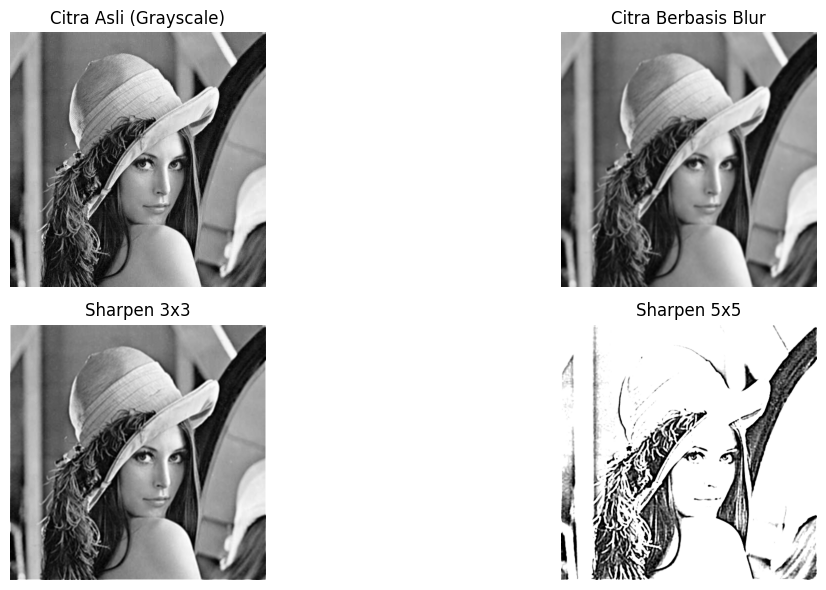

In [36]:
# Kernel Sharpening 3x3 standar
kernel_sharpen_3x3 = np.array([[ 0, -1,  0],
                               [-1,  5, -1],
                               [ 0, -1,  0]])

# Kernel Sharpening 5x5 (ekspansi bobot penajaman yang lebih luas)
kernel_sharpen_5x5 = np.array([[-1, -1, -1, -1, -1],
                               [-1,  1,  2,  1, -1],
                               [-1,  2,  7,  2, -1],
                               [-1,  1,  2,  1, -1],
                               [-1, -1, -1, -1, -1]])

# Menggunakan Gaussian Blur ringan pada img_gray
img_blurry = cv.GaussianBlur(img_gray, (5, 5), sigmaX=1.5)

# Sharpen 3x3 (padding = 1)
res_sharp_3 = convolution2d(img_blurry, kernel_sharpen_3x3, stride=1, padding=1)
res_sharp_3 = np.clip(res_sharp_3, 0, 255).astype(np.uint8)

# Sharpen 5x5 (padding = 2 karena ukuran kernel 5x5)
res_sharp_5 = convolution2d(img_blurry, kernel_sharpen_5x5, stride=1, padding=2)
res_sharp_5 = np.clip(res_sharp_5, 0, 255).astype(np.uint8)

# Visualisasi Perbandingan
titles = ['Citra Asli (Grayscale)', 'Citra Berbasis Blur', 'Sharpen 3x3', 'Sharpen 5x5']
images = [img_gray, img_blurry, res_sharp_3, res_sharp_5]

plt.figure(figsize=(14, 6))
for i in range(4):
    plt.subplot(2, 2, i + 1)
    plt.imshow(images[i], cmap='gray')
    plt.title(titles[i])
    plt.axis('off')

plt.tight_layout()
plt.show()

= Hasil Analisis:

- Terlihat pada panel Kernel 5x5 terjadi oversharpening yang ekstrem.
- Oleh karena itu, Kernel 3×3 adalah pilihan yang paling optimal dan aman untuk penggunaan sehari-hari. Ukuran ini memberikan keseimbangan terbaik (trade-off) antara pemulihan detail tepi akibat kekaburan (blur) dan pengendalian distorsi noise, serta memiliki kompleksitas komputasi yang lebih ringan.

**Tugas 3 - Filter Kartun Sederhana: `kartun(image)`**

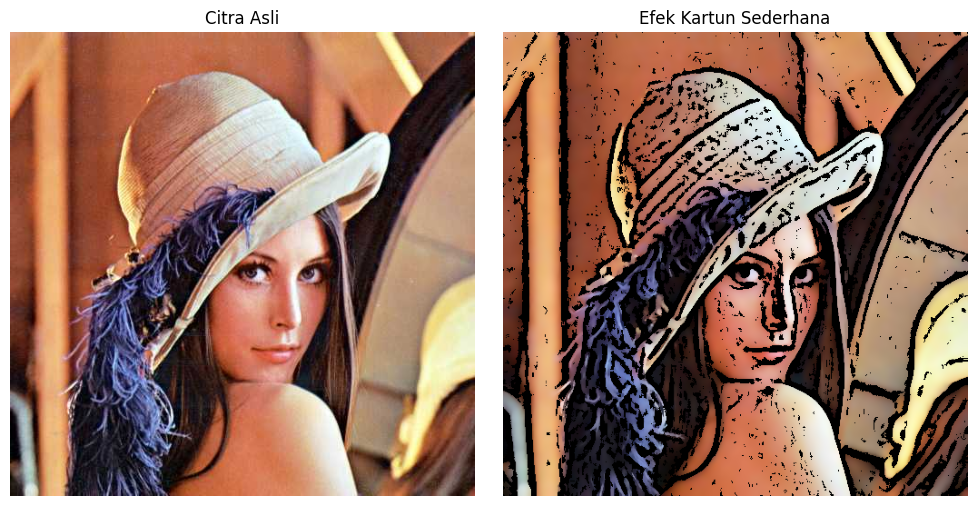

In [38]:
def kartun(image):
    if len(image.shape) == 2:
        img_bgr = cv.cvtColor(image, cv.COLOR_GRAY2BGR)
    else:
        img_bgr = image.copy()

    # 1. Penghalusan warna (Color Quantization/Smoothing) menggunakan Bilateral Filter
    color = img_bgr
    for _ in range(2):
        color = cv.bilateralFilter(color, d=9, sigmaColor=75, sigmaSpace=75)

    # 2. Deteksi Garis Tepi (Edge Detection) menggunakan Adaptive Thresholding
    gray = cv.cvtColor(img_bgr, cv.COLOR_BGR2GRAY)
    gray_blur = cv.medianBlur(gray, 7)

    # Adaptive threshold untuk mendapatkan garis tepi hitam yang tegas
    edges = cv.adaptiveThreshold(
        gray_blur, 255,
        cv.ADAPTIVE_THRESH_MEAN_C,
        cv.THRESH_BINARY,
        blockSize=9,
        C=2
    )

    # 3. Penggabungan (Kombinasi) citra warna halus dengan garis tepi
    edges_bgr = cv.cvtColor(edges, cv.COLOR_GRAY2BGR)
    cartoon = cv.bitwise_and(color, edges_bgr)
    return cartoon

img_cartoon = kartun(image)
plt.figure(figsize=(10, 5))

# Tampilkan Citra Asli
plt.subplot(1, 2, 1)
plt.imshow(cv.cvtColor(image, cv.COLOR_BGR2RGB))
plt.title('Citra Asli')
plt.axis('off')

# Tampilkan Citra Efek Kartun
plt.subplot(1, 2, 2)
plt.imshow(cv.cvtColor(img_cartoon, cv.COLOR_BGR2RGB))
plt.title('Efek Kartun Sederhana')
plt.axis('off')

plt.tight_layout()
plt.show()